# Chapter 3 Computer Lab

## Vectors, Norms, Dot Products, and Projections

This lab accompanies **Chapter 3: Vectors, Norms, Dot Products, and Projections**.

The goal is to make the formulas computational and visual:

- represent points and vectors using NumPy arrays;
- compute displacement, vector addition, scalar multiplication, norms, and unit directions;
- compute dot products, angles, orthogonality, and projections;
- use projection to decompose a vector into parallel and perpendicular components;
- interpret work as a dot product;
- use cosine similarity for data vectors;
- explore how vector geometry changes in high dimensions.

This notebook is written as a guided computer lab.  Each main topic has a short demonstration, a student workspace, and a reference solution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

rng = np.random.default_rng(2321)

print("Libraries loaded.")

Libraries loaded.


## 1. Vectors as displacement

A point gives a location.  A vector can describe a displacement from one point to another.

If

$$
A=(a_1,\ldots,a_n), \qquad B=(b_1,\ldots,b_n),
$$

then the displacement vector from $A$ to $B$ is

$$
\overrightarrow{AB}=B-A=(b_1-a_1,\ldots,b_n-a_n).
$$

In [2]:
def displacement(A, B):
    '''Return the displacement vector from point A to point B.'''
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    if A.shape != B.shape:
        raise ValueError("A and B must have the same dimension.")
    return B - A

A = np.array([1, -2, 3])
B = np.array([2, 1, 5])
AB = displacement(A, B)

print("A =", A)
print("B =", B)
print("Displacement B - A =", AB)

A = [ 1 -2  3]
B = [2 1 5]
Displacement B - A = [1. 3. 2.]


### Visualization: the same vector can be moved without changing its meaning

The vector $B-A$ gives a direction and length.  It can be drawn starting at $A$, or it can be drawn starting at the origin as a position vector.

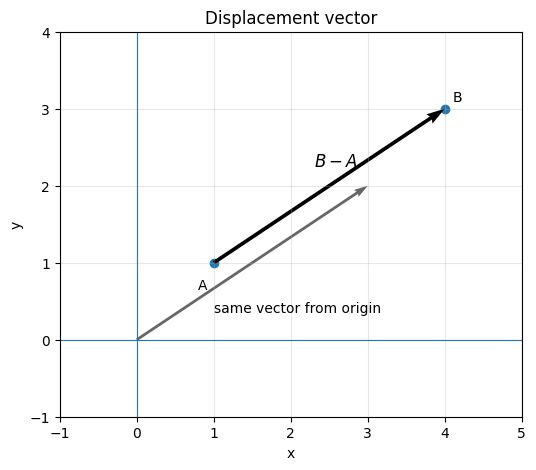

In [3]:
def setup_2d_axes(ax, xlim=(-1, 6), ylim=(-1, 5), title=None):
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    if title:
        ax.set_title(title)

A2 = np.array([1.0, 1.0])
B2 = np.array([4.0, 3.0])
AB2 = displacement(A2, B2)
O2 = np.array([0.0, 0.0])

fig, ax = plt.subplots(figsize=(6, 5))
setup_2d_axes(ax, xlim=(-1, 5), ylim=(-1, 4), title="Displacement vector")
ax.scatter([A2[0], B2[0]], [A2[1], B2[1]])
ax.text(A2[0] - 0.2, A2[1] - 0.35, "A")
ax.text(B2[0] + 0.1, B2[1] + 0.1, "B")
ax.quiver(*A2, *AB2, angles="xy", scale_units="xy", scale=1, width=0.008)
ax.quiver(*O2, *AB2, angles="xy", scale_units="xy", scale=1, width=0.006, alpha=0.6)
ax.text(2.3, 2.25, r"$B-A$", fontsize=12)
ax.text(1.0, 0.35, "same vector from origin", fontsize=10)
plt.show()

### Task 1.1

Let

$$
P=(-2,3,1), \qquad Q=(4,-1,5).
$$

Compute the displacement vector $\overrightarrow{PQ}$.  Then verify that $P+\overrightarrow{PQ}=Q$.

In [4]:
# Student workspace for Task 1.1

# P = np.array([...])
# Q = np.array([...])
# PQ = ...
# print(PQ)
# print(P + PQ)

**Reference solution.**

In [5]:
P = np.array([-2, 3, 1])
Q = np.array([4, -1, 5])
PQ = displacement(P, Q)

print("PQ =", PQ)
print("P + PQ =", P + PQ)
print("Q =", Q)

assert np.allclose(PQ, np.array([6, -4, 4]))
assert np.allclose(P + PQ, Q)

PQ = [ 6. -4.  4.]
P + PQ = [ 4. -1.  5.]
Q = [ 4 -1  5]


## 2. Vector addition and scalar multiplication

For vectors

$$
u=(u_1,\ldots,u_n), \qquad v=(v_1,\ldots,v_n),
$$

vector addition and scalar multiplication are componentwise:

$$
u+v=(u_1+v_1,\ldots,u_n+v_n),
$$

and

$$
cv=(cv_1,\ldots,cv_n).
$$

Geometrically, $u+v$ is the net displacement obtained by following $u$ and then $v$.

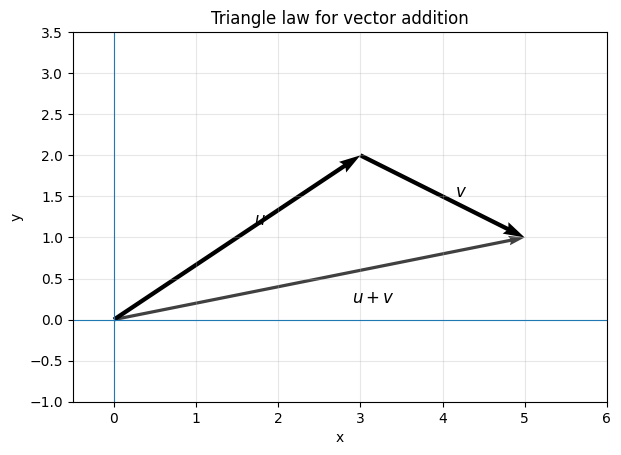

u = [3. 2.]
v = [ 2. -1.]
u + v = [5. 1.]


In [6]:
def plot_vector(ax, start, vec, label=None, label_shift=(0.05, 0.05), width=0.008, alpha=1.0):
    start = np.asarray(start, dtype=float)
    vec = np.asarray(vec, dtype=float)
    ax.quiver(*start, *vec, angles="xy", scale_units="xy", scale=1, width=width, alpha=alpha)
    if label is not None:
        midpoint = start + 0.55 * vec
        ax.text(midpoint[0] + label_shift[0], midpoint[1] + label_shift[1], label, fontsize=12)

u = np.array([3.0, 2.0])
v = np.array([2.0, -1.0])
w = u + v

fig, ax = plt.subplots(figsize=(7, 4.8))
setup_2d_axes(ax, xlim=(-0.5, 6), ylim=(-1, 3.5), title="Triangle law for vector addition")
plot_vector(ax, [0, 0], u, label=r"$u$")
plot_vector(ax, u, v, label=r"$v$")
plot_vector(ax, [0, 0], w, label=r"$u+v$", width=0.006, alpha=0.75, label_shift=(0.15, -0.35))
plt.show()

print("u =", u)
print("v =", v)
print("u + v =", w)

### Task 2.1

A particle moves by three displacements:

$$
u_1=(3,2), \qquad u_2=(-1,4), \qquad u_3=(2,-5).
$$

Compute the net displacement and final location if the initial point is $A=(1,-2)$.

In [7]:
# Student workspace for Task 2.1

# u1 = np.array([...])
# u2 = np.array([...])
# u3 = np.array([...])
# A = np.array([...])
# net = ...
# final = ...

**Reference solution.**

In [8]:
u1 = np.array([3, 2])
u2 = np.array([-1, 4])
u3 = np.array([2, -5])
A = np.array([1, -2])

net = u1 + u2 + u3
final = A + net

print("net displacement =", net)
print("final location =", final)

assert np.allclose(net, np.array([4, 1]))
assert np.allclose(final, np.array([5, -1]))

net displacement = [4 1]
final location = [ 5 -1]


### Scalar multiplication

Multiplying by $c$ scales the vector length by $|c|$.  If $c<0$, the direction is reversed.

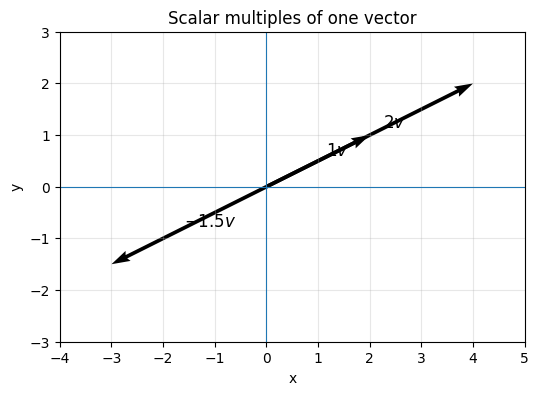

In [9]:
v = np.array([2.0, 1.0])
scalars = [1, 2, -1.5]

fig, ax = plt.subplots(figsize=(6, 5))
setup_2d_axes(ax, xlim=(-4, 5), ylim=(-3, 3), title="Scalar multiples of one vector")
for c in scalars:
    plot_vector(ax, [0, 0], c * v, label=fr"${c}v$", width=0.008)
plt.show()

## 3. Norms, distances, and unit vectors

The Euclidean norm of

$$
v=(v_1,\ldots,v_n)
$$

is

$$
\|v\|=\sqrt{v_1^2+\cdots+v_n^2}.
$$

If $v\ne 0$, the unit vector in the direction of $v$ is

$$
\widehat v=\frac{v}{\|v\|}.
$$

In [10]:
def norm(v):
    '''Euclidean norm of a vector.'''
    v = np.asarray(v, dtype=float)
    return np.sqrt(np.sum(v * v))

def unit(v):
    '''Unit vector in the direction of v.'''
    v = np.asarray(v, dtype=float)
    length = norm(v)
    if np.isclose(length, 0):
        raise ValueError("The zero vector has no unit direction.")
    return v / length

def distance(A, B):
    '''Euclidean distance between points A and B.'''
    return norm(displacement(A, B))

v = np.array([3.0, -4.0])
vhat = unit(v)

print("v =", v)
print("||v|| =", norm(v))
print("unit direction =", vhat)
print("norm of unit direction =", norm(vhat))

v = [ 3. -4.]
||v|| = 5.0
unit direction = [ 0.6 -0.8]
norm of unit direction = 1.0


### Task 3.1

Find a unit vector in the direction of

$$
v=(6,8).
$$

Then verify computationally that the unit vector has norm $1$.

In [11]:
# Student workspace for Task 3.1

# v = np.array([...])
# vhat = ...
# print(vhat)
# print(norm(vhat))

**Reference solution.**

In [12]:
v = np.array([6.0, 8.0])
vhat = unit(v)

print("||v|| =", norm(v))
print("vhat =", vhat)
print("||vhat|| =", norm(vhat))

assert np.allclose(vhat, np.array([0.6, 0.8]))
assert np.allclose(norm(vhat), 1)

||v|| = 10.0
vhat = [0.6 0.8]
||vhat|| = 1.0


### Task 3.2

Find the distance between

$$
A=(2,-1,4), \qquad B=(5,3,-2).
$$

In [13]:
# Student workspace for Task 3.2

# A = np.array([...])
# B = np.array([...])
# print(distance(A, B))

**Reference solution.**

In [14]:
A = np.array([2, -1, 4])
B = np.array([5, 3, -2])

print("B - A =", displacement(A, B))
print("distance(A, B) =", distance(A, B))
print("exact form: sqrt(61)")

assert np.allclose(distance(A, B), np.sqrt(61))

B - A = [ 3.  4. -6.]
distance(A, B) = 7.810249675906654
exact form: sqrt(61)


### Perpendicular unit vectors in the plane

For a nonzero vector $v=(a,b)$, both $(-b,a)$ and $(b,-a)$ are perpendicular to $v$.

In [15]:
def perpendicular_2d(v):
    '''Return one perpendicular vector to a 2D vector v.'''
    v = np.asarray(v, dtype=float)
    if v.shape != (2,):
        raise ValueError("This helper is only for 2D vectors.")
    return np.array([-v[1], v[0]])

v = np.array([3.0, -4.0])
p = perpendicular_2d(v)
p_hat = unit(p)

print("v =", v)
print("a perpendicular vector =", p)
print("dot product v dot p =", v @ p)
print("unit perpendicular vector =", p_hat)

v = [ 3. -4.]
a perpendicular vector = [4. 3.]
dot product v dot p = 0.0
unit perpendicular vector = [0.8 0.6]


## 4. Dot products, angles, and orthogonality

The dot product of

$$
u=(u_1,\ldots,u_n), \qquad v=(v_1,\ldots,v_n)
$$

is

$$
u\cdot v=u_1v_1+\cdots+u_nv_n.
$$

It satisfies the geometric identity

$$
u\cdot v=\|u\|\,\|v\|\cos\theta,
$$

where $\theta$ is the angle between the two nonzero vectors.

In [16]:
def dot(u, v):
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    if u.shape != v.shape:
        raise ValueError("u and v must have the same dimension.")
    return float(u @ v)

def cosine_similarity(u, v):
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    denom = norm(u) * norm(v)
    if np.isclose(denom, 0):
        raise ValueError("Cosine similarity is undefined for the zero vector.")
    return dot(u, v) / denom

def angle_between(u, v, degrees=False):
    c = cosine_similarity(u, v)
    c = np.clip(c, -1.0, 1.0)
    theta = np.arccos(c)
    if degrees:
        return np.degrees(theta)
    return theta

F = np.array([1.0, 2.0])
v = np.array([-1.0, 3.0])

print("F dot v =", dot(F, v))
print("cos(theta) =", cosine_similarity(F, v))
print("theta in radians =", angle_between(F, v))
print("theta in degrees =", angle_between(F, v, degrees=True))

F dot v = 5.0
cos(theta) = 0.7071067811865475
theta in radians = 0.7853981633974484
theta in degrees = 45.00000000000001


### Task 4.1

Let

$$
u=(2,-1,3), \qquad v=(1,5,1).
$$

Compute $u\cdot v$.  Are $u$ and $v$ orthogonal?

In [17]:
# Student workspace for Task 4.1

# u = np.array([...])
# v = np.array([...])
# print(dot(u, v))
# print(np.isclose(dot(u, v), 0))

**Reference solution.**

In [18]:
u = np.array([2, -1, 3])
v = np.array([1, 5, 1])

d = dot(u, v)
print("u dot v =", d)
print("Orthogonal?", np.isclose(d, 0))

assert np.isclose(d, 0)

u dot v = 0.0
Orthogonal? True


### Task 4.2

Find the angle between

$$
u=(1,1), \qquad v=(1,-1).
$$

Give the answer in radians and degrees.

In [19]:
# Student workspace for Task 4.2

# u = np.array([...])
# v = np.array([...])
# print(angle_between(u, v))
# print(angle_between(u, v, degrees=True))

**Reference solution.**

In [20]:
u = np.array([1, 1])
v = np.array([1, -1])

theta_rad = angle_between(u, v)
theta_deg = angle_between(u, v, degrees=True)

print("cos(theta) =", cosine_similarity(u, v))
print("theta =", theta_rad, "radians")
print("theta =", theta_deg, "degrees")

assert np.allclose(theta_rad, np.pi/2)
assert np.allclose(theta_deg, 90)

cos(theta) = 0.0
theta = 1.5707963267948966 radians
theta = 90.0 degrees


### Visualization: dot product sign and angle

Positive dot product means acute angle.  Zero dot product means a right angle.  Negative dot product means obtuse angle.

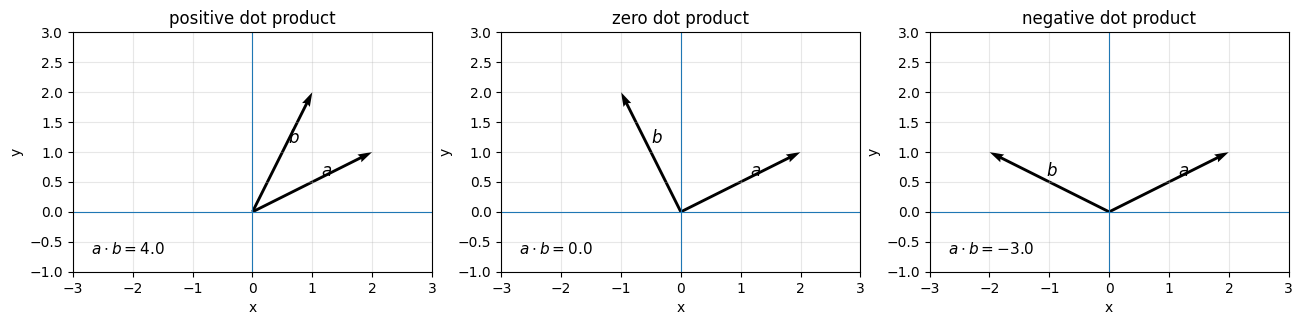

In [21]:
examples = [
    (np.array([2.0, 1.0]), np.array([1.0, 2.0]), "positive dot product"),
    (np.array([2.0, 1.0]), np.array([-1.0, 2.0]), "zero dot product"),
    (np.array([2.0, 1.0]), np.array([-2.0, 1.0]), "negative dot product"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (a, b, title) in zip(axes, examples):
    setup_2d_axes(ax, xlim=(-3, 3), ylim=(-1, 3), title=title)
    plot_vector(ax, [0, 0], a, label=r"$a$")
    plot_vector(ax, [0, 0], b, label=r"$b$")
    ax.text(-2.7, -0.7, fr"$a\cdot b={dot(a,b):.1f}$", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Projection and orthogonal decomposition

Let $v\ne 0$.  The projection of $u$ onto $v$ is

$$
\operatorname{proj}_v(u)=\frac{u\cdot v}{v\cdot v}v.
$$

This produces a decomposition

$$
u=p+r,
$$

where

$$
p=\operatorname{proj}_v(u)
$$

is parallel to $v$, and

$$
r=u-p
$$

is orthogonal to $v$.

In [22]:
def projection(u, v):
    '''Project vector u onto the line spanned by nonzero vector v.'''
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    denom = dot(v, v)
    if np.isclose(denom, 0):
        raise ValueError("Cannot project onto the zero vector.")
    return (dot(u, v) / denom) * v

def projection_decomposition(u, v):
    p = projection(u, v)
    r = np.asarray(u, dtype=float) - p
    return p, r

u = np.array([1.0, 2.0])
v = np.array([-1.0, 3.0])
p, r = projection_decomposition(u, v)

print("u =", u)
print("v =", v)
print("projection p =", p)
print("residual r =", r)
print("p + r =", p + r)
print("r dot v =", dot(r, v))

u = [1. 2.]
v = [-1.  3.]
projection p = [-0.5  1.5]
residual r = [1.5 0.5]
p + r = [1. 2.]
r dot v = 0.0


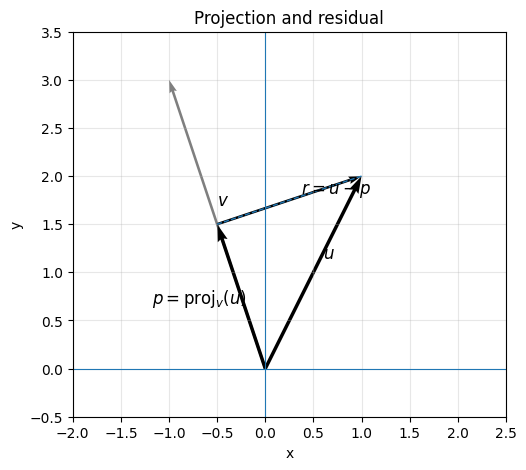

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
setup_2d_axes(ax, xlim=(-2, 2.5), ylim=(-0.5, 3.5), title="Projection and residual")
plot_vector(ax, [0, 0], u, label=r"$u$", width=0.008)
plot_vector(ax, [0, 0], v, label=r"$v$", width=0.006, alpha=0.5)
plot_vector(ax, [0, 0], p, label=r"$p=\mathrm{proj}_v(u)$", width=0.008, label_shift=(-0.9, -0.15))
plot_vector(ax, p, r, label=r"$r=u-p$", width=0.006)
ax.plot([u[0], p[0]], [u[1], p[1]], linestyle="--", linewidth=1)
plt.show()

### Task 5.1

Find the projection of

$$
u=(3,4)
$$

onto

$$
v=(1,0).
$$

Interpret the result geometrically.

In [24]:
# Student workspace for Task 5.1

# u = np.array([...])
# v = np.array([...])
# print(projection(u, v))

**Reference solution.**

In [25]:
u = np.array([3.0, 4.0])
v = np.array([1.0, 0.0])
p = projection(u, v)
r = u - p

print("projection =", p)
print("residual =", r)
print("residual dot v =", dot(r, v))
print("Interpretation: keep the x-component and remove the y-component.")

assert np.allclose(p, np.array([3, 0]))
assert np.allclose(dot(r, v), 0)

projection = [3. 0.]
residual = [0. 4.]
residual dot v = 0.0
Interpretation: keep the x-component and remove the y-component.


### Task 5.2

Find the projection of

$$
u=(1,2)
$$

onto

$$
v=(-1,3).
$$

Then verify that the residual $u-\operatorname{proj}_v(u)$ is orthogonal to $v$.

In [26]:
# Student workspace for Task 5.2

# u = np.array([...])
# v = np.array([...])
# p, r = projection_decomposition(u, v)
# print(p)
# print(r)
# print(dot(r, v))

**Reference solution.**

In [27]:
u = np.array([1.0, 2.0])
v = np.array([-1.0, 3.0])
p, r = projection_decomposition(u, v)

print("projection =", p)
print("residual =", r)
print("residual dot v =", dot(r, v))

assert np.allclose(p, np.array([-0.5, 1.5]))
assert np.allclose(dot(r, v), 0)

projection = [-0.5  1.5]
residual = [1.5 0.5]
residual dot v = 0.0


### Projection as the best approximation on a line

The projection $p=\operatorname{proj}_v(u)$ is the closest point to $u$ on the line spanned by $v$.

Equivalently, if we search over vectors of the form $cv$, the best coefficient is

$$
c^*=\frac{u\cdot v}{v\cdot v}.
$$

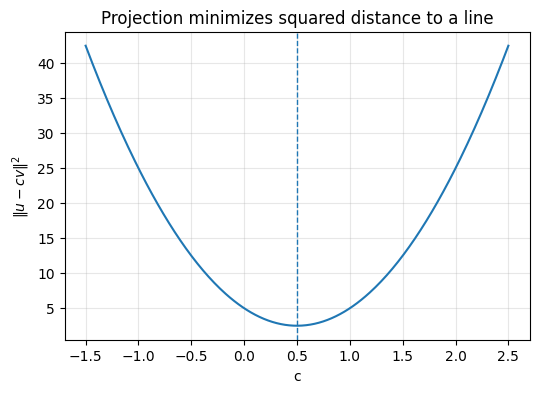

best coefficient c* = 0.5
projection c* v = [-0.5  1.5]


In [28]:
u = np.array([1.0, 2.0])
v = np.array([-1.0, 3.0])

c_star = dot(u, v) / dot(v, v)
cs = np.linspace(c_star - 2, c_star + 2, 300)
errors = np.array([norm(u - c * v)**2 for c in cs])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(cs, errors)
ax.axvline(c_star, linestyle="--", linewidth=1)
ax.set_xlabel("c")
ax.set_ylabel(r"$\|u-cv\|^2$")
ax.set_title("Projection minimizes squared distance to a line")
ax.grid(True, alpha=0.3)
plt.show()

print("best coefficient c* =", c_star)
print("projection c* v =", c_star * v)

## 6. Work as a dot product

If a constant force $F$ moves an object through a displacement $d$, then the work done is

$$
W=F\cdot d.
$$

Only the component of force in the direction of motion contributes to work.

In [29]:
def work(F, A, B):
    '''Work done by constant force F moving an object from A to B.'''
    F = np.asarray(F, dtype=float)
    d = displacement(A, B)
    if F.shape != d.shape:
        raise ValueError("Force and displacement must have the same dimension.")
    return dot(F, d)

F = np.array([-1, -3, 4])
A = np.array([1, 2, 0])
B = np.array([2, 0, 1])

print("displacement =", displacement(A, B))
print("work =", work(F, A, B))

displacement = [ 1. -2.  1.]
work = 9.0


### Task 6.1

A force

$$
F=(2,-1,4)
$$

moves an object from

$$
A=(0,1,2)
$$

to

$$
B=(3,0,5).
$$

Compute the work done.

In [30]:
# Student workspace for Task 6.1

# F = np.array([...])
# A = np.array([...])
# B = np.array([...])
# print(work(F, A, B))

**Reference solution.**

In [31]:
F = np.array([2, -1, 4])
A = np.array([0, 1, 2])
B = np.array([3, 0, 5])

d = displacement(A, B)
W = work(F, A, B)

print("d = B - A =", d)
print("W = F dot d =", W)

assert np.isclose(W, 19)

d = B - A = [ 3. -1.  3.]
W = F dot d = 19.0


## 7. Cosine similarity for data vectors

For nonzero vectors $u$ and $v$,

$$
\operatorname{cosine\ similarity}(u,v)=\frac{u\cdot v}{\|u\|\|v\|}.
$$

This is the cosine of the angle between them.  It measures direction rather than magnitude.

In [32]:
x = np.array([2, 1, 0, 3], dtype=float)
y = np.array([4, 2, 0, 6], dtype=float)
z = np.array([0, 3, 4, 0], dtype=float)

print("cosine(x, y) =", cosine_similarity(x, y))
print("cosine(x, z) =", cosine_similarity(x, z))
print("cosine(y, z) =", cosine_similarity(y, z))

cosine(x, y) = 1.0
cosine(x, z) = 0.16035674514745463
cosine(y, z) = 0.16035674514745463


### Task 7.1

Let

$$
x=(1,0,2,2), \qquad y=(2,0,4,4).
$$

Compute their cosine similarity.  Explain why the answer is exactly $1$.

In [33]:
# Student workspace for Task 7.1

# x = np.array([...])
# y = np.array([...])
# print(cosine_similarity(x, y))

**Reference solution.**

In [34]:
x = np.array([1, 0, 2, 2], dtype=float)
y = np.array([2, 0, 4, 4], dtype=float)

sim = cosine_similarity(x, y)
print("cosine similarity =", sim)
print("Since y = 2x, the vectors have the same direction.")

assert np.allclose(sim, 1)

cosine similarity = 1.0
Since y = 2x, the vectors have the same direction.


### Cosine similarity matrix

A collection of data vectors can be compared all at once by normalizing each row to unit length and multiplying the normalized matrix by its transpose.

[[1.     0.9286 0.1604 0.5455]
 [0.9286 1.     0.1604 0.5455]
 [0.1604 0.1604 1.     0.6532]
 [0.5455 0.5455 0.6532 1.    ]]


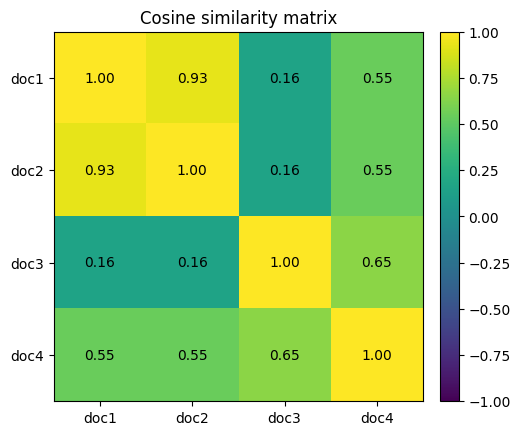

In [35]:
def row_normalize(X):
    X = np.asarray(X, dtype=float)
    row_norms = np.linalg.norm(X, axis=1, keepdims=True)
    if np.any(np.isclose(row_norms, 0)):
        raise ValueError("Cannot normalize a zero row.")
    return X / row_norms

vectors = np.array([
    [3, 1, 0, 2],
    [2, 1, 0, 3],
    [0, 3, 4, 0],
    [1, 0, 2, 1],
], dtype=float)
labels = ["doc1", "doc2", "doc3", "doc4"]

U = row_normalize(vectors)
S = U @ U.T

print(S)

fig, ax = plt.subplots(figsize=(5.5, 4.8))
im = ax.imshow(S, vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)), labels)
ax.set_yticks(range(len(labels)), labels)
for i in range(S.shape[0]):
    for j in range(S.shape[1]):
        ax.text(j, i, f"{S[i, j]:.2f}", ha="center", va="center")
ax.set_title("Cosine similarity matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## 8. Norms beyond the Euclidean norm

For $v=(v_1,\ldots,v_n)$, three common norms are

$$
\|v\|_1=|v_1|+\cdots+|v_n|,
$$

$$
\|v\|_2=\sqrt{v_1^2+\cdots+v_n^2},
$$

and

$$
\|v\|_\infty=\max_i |v_i|.
$$

Different norms define different ideas of size and distance.

In [36]:
def norm1(v):
    v = np.asarray(v, dtype=float)
    return np.sum(np.abs(v))

def norm2(v):
    return norm(v)

def norm_inf(v):
    v = np.asarray(v, dtype=float)
    return np.max(np.abs(v))

v = np.array([3.0, -4.0, 12.0])
print("v =", v)
print("L1 norm =", norm1(v))
print("L2 norm =", norm2(v))
print("L-infinity norm =", norm_inf(v))

v = [ 3. -4. 12.]
L1 norm = 19.0
L2 norm = 13.0
L-infinity norm = 12.0


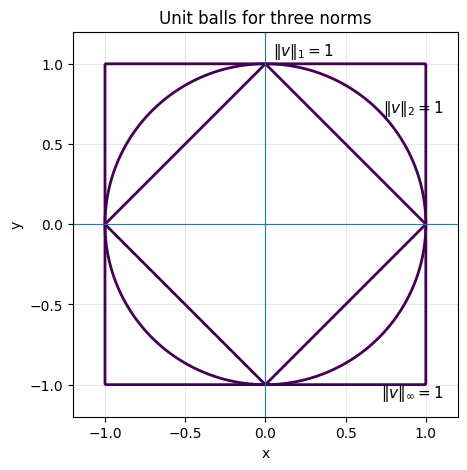

In [37]:
xgrid = np.linspace(-1.2, 1.2, 400)
ygrid = np.linspace(-1.2, 1.2, 400)
X, Y = np.meshgrid(xgrid, ygrid)
L1 = np.abs(X) + np.abs(Y)
L2 = np.sqrt(X**2 + Y**2)
Linf = np.maximum(np.abs(X), np.abs(Y))

fig, ax = plt.subplots(figsize=(6, 5))
ax.contour(X, Y, L1, levels=[1], linewidths=2)
ax.contour(X, Y, L2, levels=[1], linewidths=2)
ax.contour(X, Y, Linf, levels=[1], linewidths=2)
setup_2d_axes(ax, xlim=(-1.2, 1.2), ylim=(-1.2, 1.2), title="Unit balls for three norms")
ax.text(0.05, 1.05, r"$\|v\|_1=1$", fontsize=11)
ax.text(0.73, 0.70, r"$\|v\|_2=1$", fontsize=11)
ax.text(0.72, -1.08, r"$\|v\|_\infty=1$", fontsize=11)
plt.show()

### Task 8.1

For

$$
v=(-2,5,-1),
$$

compute $\|v\|_1$, $\|v\|_2$, and $\|v\|_\infty$.

In [38]:
# Student workspace for Task 8.1

# v = np.array([...])
# print(norm1(v), norm2(v), norm_inf(v))

**Reference solution.**

In [39]:
v = np.array([-2, 5, -1], dtype=float)

print("L1 =", norm1(v))
print("L2 =", norm2(v))
print("L-infinity =", norm_inf(v))

assert np.allclose(norm1(v), 8)
assert np.allclose(norm2(v), np.sqrt(30))
assert np.allclose(norm_inf(v), 5)

L1 = 8.0
L2 = 5.477225575051661
L-infinity = 5.0


## 9. Feature scaling and distance

Distances between data vectors can change dramatically if one feature has a much larger scale than another.  This is why feature scaling is important in nearest-neighbor methods and clustering.

In [40]:
query = np.array([170.0, 70.0])      # height in cm, weight in kg
A = np.array([172.0, 72.0])          # similar height and weight
B = np.array([185.0, 71.0])          # taller but similar weight
C = np.array([170.5, 95.0])          # similar height but much heavier
points = np.array([A, B, C])
names = ["A", "B", "C"]

raw_distances = np.array([distance(query, p) for p in points])

print("Raw distances from query:")
for name, d in zip(names, raw_distances):
    print(name, d)
print("Nearest using raw distance:", names[np.argmin(raw_distances)])

Raw distances from query:
A 2.8284271247461903
B 15.033296378372908
C 25.004999500099974
Nearest using raw distance: A


Now rescale the features using hypothetical standard deviations.  For example, height may vary by about 10 cm, while weight may vary by about 15 kg.  Standardizing makes the two coordinates more comparable.

In [41]:
scales = np.array([10.0, 15.0])
query_scaled = query / scales
points_scaled = points / scales
scaled_distances = np.array([distance(query_scaled, p) for p in points_scaled])

print("Scaled distances from query:")
for name, d in zip(names, scaled_distances):
    print(name, d)
print("Nearest using scaled distance:", names[np.argmin(scaled_distances)])

Scaled distances from query:
A 0.24037008503093177
B 1.501480750607361
C 1.667416497992561
Nearest using scaled distance: A


### Task 9.1

Create your own query point and three candidate points in $\mathbb R^2$.  Compute the nearest point before and after scaling the coordinates.  Try to find an example where the nearest point changes.

In [42]:
# Student workspace for Task 9.1

# query = np.array([...])
# points = np.array([[...], [...], [...]])
# scales = np.array([...])
# raw_distances = np.array([distance(query, p) for p in points])
# scaled_distances = np.array([distance(query / scales, p / scales) for p in points])
# print(raw_distances)
# print(scaled_distances)

**Reference solution.**

In [43]:
query = np.array([0.0, 0.0])
points = np.array([
    [8.0, 0.9],
    [1.0, 2.0],
    [3.0, 1.5],
])
labels = ["A", "B", "C"]
scales = np.array([10.0, 1.0])

raw_distances = np.array([distance(query, p) for p in points])
scaled_distances = np.array([distance(query / scales, p / scales) for p in points])

print("Raw distances:", raw_distances)
print("Nearest raw:", labels[np.argmin(raw_distances)])
print("Scaled distances:", scaled_distances)
print("Nearest scaled:", labels[np.argmin(scaled_distances)])

Raw distances: [8.0505 2.2361 3.3541]
Nearest raw: B
Scaled distances: [1.2042 2.0025 1.5297]
Nearest scaled: A


## 10. High-dimensional geometry

In high dimensions, random directions tend to be nearly orthogonal.  We can see this by simulating random unit vectors and computing their dot products.

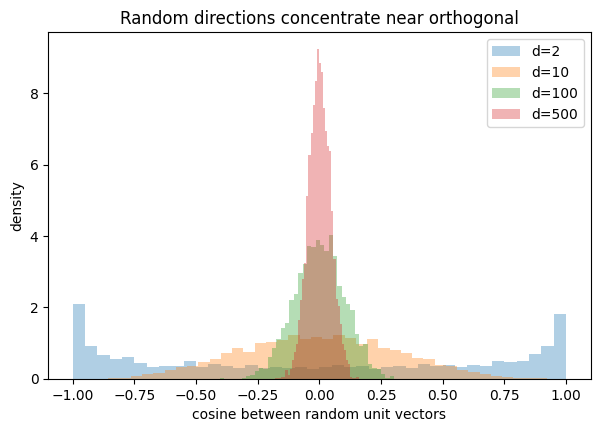

dimension | mean cosine | std cosine | mean absolute cosine
        2 |     -0.0210 |     0.7044 |               0.6336
       10 |     -0.0044 |     0.3144 |               0.2565
      100 |      0.0002 |     0.1006 |               0.0809
      500 |      0.0008 |     0.0452 |               0.0360


In [44]:
def random_unit_vectors(num_vectors, dimension, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    X = rng.normal(size=(num_vectors, dimension))
    return row_normalize(X)

num_pairs = 4000
dimensions = [2, 10, 100, 500]

fig, ax = plt.subplots(figsize=(7, 4.5))
summary = []
for d in dimensions:
    A = random_unit_vectors(num_pairs, d, rng)
    B = random_unit_vectors(num_pairs, d, rng)
    cosines = np.sum(A * B, axis=1)
    summary.append((d, np.mean(cosines), np.std(cosines), np.mean(np.abs(cosines))))
    ax.hist(cosines, bins=40, alpha=0.35, density=True, label=f"d={d}")

ax.set_xlabel("cosine between random unit vectors")
ax.set_ylabel("density")
ax.set_title("Random directions concentrate near orthogonal")
ax.legend()
plt.show()

print("dimension | mean cosine | std cosine | mean absolute cosine")
for d, mean_c, std_c, mean_abs in summary:
    print(f"{d:9d} | {mean_c:11.4f} | {std_c:10.4f} | {mean_abs:20.4f}")

### Task 10.1

Repeat the simulation for dimensions $5$, $50$, and $1000$.  What happens to the standard deviation of the cosine values as dimension increases?

In [45]:
# Student workspace for Task 10.1

# for d in [5, 50, 1000]:
#     A = random_unit_vectors(2000, d, rng)
#     B = random_unit_vectors(2000, d, rng)
#     cosines = np.sum(A * B, axis=1)
#     print(d, np.std(cosines))

**Reference solution.**

In [46]:
for d in [5, 50, 1000]:
    A = random_unit_vectors(2000, d, rng)
    B = random_unit_vectors(2000, d, rng)
    cosines = np.sum(A * B, axis=1)
    print(f"dimension {d:4d}: std(cosine) = {np.std(cosines):.4f}")

print("The spread decreases as the dimension increases.")

dimension    5: std(cosine) = 0.4388
dimension   50: std(cosine) = 0.1416
dimension 1000: std(cosine) = 0.0317
The spread decreases as the dimension increases.


## 11. Projection bridge to least squares

Projection is the geometric idea behind least-squares approximation.

Suppose we have a response vector $y$ and a single feature vector $x$.  We want to approximate $y$ by a multiple of $x$:

$$
\widehat y=cx.
$$

The best coefficient is

$$
c=\frac{x\cdot y}{x\cdot x}.
$$

The residual vector

$$
r=y-\widehat y
$$

is orthogonal to $x$.

In [47]:
x = np.array([1.0, 2.0, 3.0, 4.0])
y = np.array([1.2, 1.9, 3.2, 3.9])

c = dot(x, y) / dot(x, x)
y_hat = c * x
residual = y - y_hat

print("x =", x)
print("y =", y)
print("best c =", c)
print("y_hat =", y_hat)
print("residual =", residual)
print("x dot residual =", dot(x, residual))

x = [1. 2. 3. 4.]
y = [1.2 1.9 3.2 3.9]
best c = 1.0066666666666668
y_hat = [1.0067 2.0133 3.02   4.0267]
residual = [ 0.1933 -0.1133  0.18   -0.1267]
x dot residual = -4.6629367034256575e-15


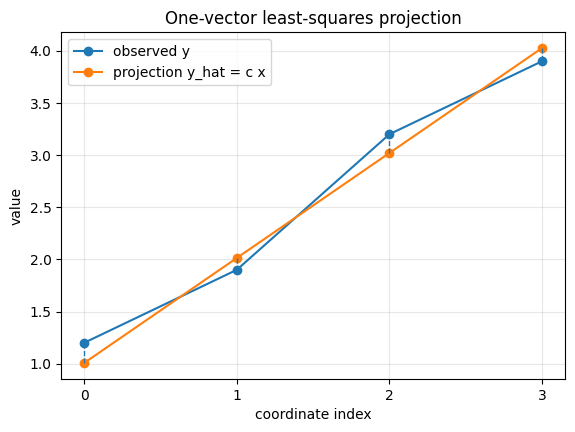

In [48]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
indices = np.arange(len(x))
ax.plot(indices, y, marker="o", label="observed y")
ax.plot(indices, y_hat, marker="o", label="projection y_hat = c x")
ax.vlines(indices, y_hat, y, linestyle="--", linewidth=1)
ax.set_xticks(indices)
ax.set_xlabel("coordinate index")
ax.set_ylabel("value")
ax.set_title("One-vector least-squares projection")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### Task 11.1

Let

$$
x=(1,1,2), \qquad y=(2,0,4).
$$

Find the best approximation $\widehat y=cx$ and verify that $x\cdot (y-\widehat y)=0$.

In [49]:
# Student workspace for Task 11.1

# x = np.array([...], dtype=float)
# y = np.array([...], dtype=float)
# c = ...
# y_hat = ...
# residual = ...
# print(c, y_hat, residual, dot(x, residual))

**Reference solution.**

In [50]:
x = np.array([1, 1, 2], dtype=float)
y = np.array([2, 0, 4], dtype=float)

c = dot(x, y) / dot(x, x)
y_hat = c * x
residual = y - y_hat

print("c =", c)
print("y_hat =", y_hat)
print("residual =", residual)
print("x dot residual =", dot(x, residual))

assert np.allclose(dot(x, residual), 0)

c = 1.6666666666666667
y_hat = [1.6667 1.6667 3.3333]
residual = [ 0.3333 -1.6667  0.6667]
x dot residual = -4.440892098500626e-16


## 12. Mini-project: document similarity search

In a simple bag-of-words model, each document is represented by a word-count vector.

Suppose our vocabulary is

$$
(\text{calculus},\text{data},\text{matrix},\text{gradient},\text{probability}).
$$

We will use cosine similarity to search for documents similar to a query.

In [51]:
vocabulary = ["calculus", "data", "matrix", "gradient", "probability"]

docs = np.array([
    [4, 1, 0, 2, 0],  # multivariable calculus and gradients
    [0, 3, 4, 0, 1],  # data and matrices
    [1, 0, 0, 3, 0],  # gradient-heavy calculus
    [0, 2, 1, 0, 5],  # probability/data
    [3, 1, 1, 2, 0],  # calculus, data, matrix, gradient
], dtype=float)

doc_names = ["doc_A", "doc_B", "doc_C", "doc_D", "doc_E"]
query = np.array([2, 0, 0, 1, 0], dtype=float)  # calculus + gradient

query_unit = unit(query)
docs_unit = row_normalize(docs)
scores = docs_unit @ query_unit

order = np.argsort(-scores)

print("Vocabulary:", vocabulary)
print("Query:", query)
print("\nSimilarity ranking:")
for idx in order:
    print(f"{doc_names[idx]}: score={scores[idx]:.3f}, vector={docs[idx]}")

Vocabulary: ['calculus', 'data', 'matrix', 'gradient', 'probability']
Query: [2. 0. 0. 1. 0.]

Similarity ranking:
doc_A: score=0.976, vector=[4. 1. 0. 2. 0.]
doc_E: score=0.924, vector=[3. 1. 1. 2. 0.]
doc_C: score=0.707, vector=[1. 0. 0. 3. 0.]
doc_B: score=0.000, vector=[0. 3. 4. 0. 1.]
doc_D: score=0.000, vector=[0. 2. 1. 0. 5.]


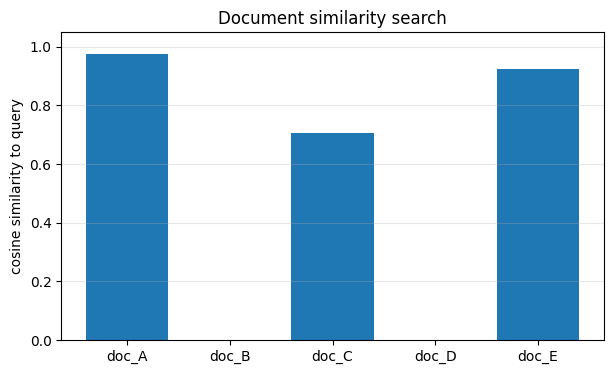

In [52]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(np.arange(len(doc_names)), scores)
ax.set_xticks(np.arange(len(doc_names)), doc_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel("cosine similarity to query")
ax.set_title("Document similarity search")
ax.grid(True, axis="y", alpha=0.3)
plt.show()

### Task 12.1

Change the query vector to emphasize **data** and **probability**:

$$
q=(0,2,0,0,3).
$$

Compute the new ranking.

In [53]:
# Student workspace for Task 12.1

# query = np.array([0, 2, 0, 0, 3], dtype=float)
# scores = docs_unit @ unit(query)
# order = np.argsort(-scores)
# for idx in order:
#     print(doc_names[idx], scores[idx])

**Reference solution.**

In [54]:
query = np.array([0, 2, 0, 0, 3], dtype=float)
scores = docs_unit @ unit(query)
order = np.argsort(-scores)

print("New query:", query)
print("\nNew similarity ranking:")
for idx in order:
    print(f"{doc_names[idx]}: score={scores[idx]:.3f}, vector={docs[idx]}")

New query: [0. 2. 0. 0. 3.]

New similarity ranking:
doc_D: score=0.962, vector=[0. 2. 1. 0. 5.]
doc_B: score=0.490, vector=[0. 3. 4. 0. 1.]
doc_E: score=0.143, vector=[3. 1. 1. 2. 0.]
doc_A: score=0.121, vector=[4. 1. 0. 2. 0.]
doc_C: score=0.000, vector=[1. 0. 0. 3. 0.]


## 13. Challenge problems with computational checks

These problems connect the chapter formulas to important mathematical facts.

### Challenge 13.1: Cauchy--Schwarz inequality

For many random pairs of vectors, check numerically that

$$
|u\cdot v|\le \|u\|\|v\|.
$$

In [55]:
violations = 0
max_gap = -np.inf

for _ in range(5000):
    u = rng.normal(size=20)
    v = rng.normal(size=20)
    left = abs(dot(u, v))
    right = norm(u) * norm(v)
    if left > right + 1e-10:
        violations += 1
    max_gap = max(max_gap, left - right)

print("number of violations =", violations)
print("maximum left - right =", max_gap)

assert violations == 0

number of violations = 0
maximum left - right = -4.654188965489659


### Challenge 13.2: Projection residual is orthogonal

Generate random vectors $u$ and $v$, project $u$ onto $v$, and check that the residual is orthogonal to $v$.

In [56]:
max_abs_residual_dot = 0.0

for _ in range(1000):
    u = rng.normal(size=8)
    v = rng.normal(size=8)
    p, r = projection_decomposition(u, v)
    max_abs_residual_dot = max(max_abs_residual_dot, abs(dot(r, v)))

print("largest |residual dot v| =", max_abs_residual_dot)

assert max_abs_residual_dot < 1e-10

largest |residual dot v| = 2.3500307186643405e-15


### Challenge 13.3: Cosine similarity is invariant under positive scaling

If $a>0$ and $b>0$, then

$$
\operatorname{cosine}(au,bv)=\operatorname{cosine}(u,v).
$$

Check this numerically.

In [57]:
u = rng.normal(size=10)
v = rng.normal(size=10)
a = 7.5
b = 0.2

original = cosine_similarity(u, v)
scaled = cosine_similarity(a * u, b * v)

print("original cosine =", original)
print("scaled cosine =", scaled)
print("difference =", scaled - original)

assert np.allclose(original, scaled)

original cosine = 0.22441760118466636
scaled cosine = 0.22441760118466628
difference = -8.326672684688674e-17


## 14. Lab summary

In this lab, you used Python to compute and visualize the main operations from Chapter 3.

You should now be able to:

- represent vectors and points using NumPy arrays;
- compute displacements, norms, distances, and unit vectors;
- add and scale vectors;
- compute dot products and angles;
- recognize and verify orthogonality;
- compute projections and residuals;
- interpret work as a dot product;
- use cosine similarity for data vectors;
- compare different norms;
- understand why projections are the starting point for least squares;
- see why high-dimensional random directions are nearly orthogonal.

The main conceptual lesson is this:

> Dot products and projections turn geometry into computation.  This is why they are central in multivariable calculus, statistics, data science, optimization, and machine learning.